In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
for col in df:
    print(str(col)+" : "+str(df[col].unique()))


v1 : ['ham' 'spam']
v2 : ['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 ... 'Pity, * was in mood for that. So...any other suggestions?'
 "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
 'Rofl. Its true to its name']
Unnamed: 2 : [nan ' PO Box 5249'
 ' the person is definitely special for u..... But if the person is so special'
 ' HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE JEN XXX\\""'
 ' wanted to say hi. HI!!!\\" Stop? Send STOP to 62468"'
 'this wont even start........ Datz confidence.."' 'GN' '.;-):-D"'
 'just been in bedbut mite go 2 thepub l8tr if uwana mt up?loads a luv Jenxxx.\\""'
 ' bt not his girlfrnd... G o o d n i g h t . . .@"' ' I\'ll 

In [6]:
# Source - https://stackoverflow.com/a/51071037
# Posted by Engineero, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-26, License - CC BY-SA 4.0

percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df

,column_name,percent_missing
v1,v1,0.000000
v2,v2,0.000000
Unnamed: 2,Unnamed: 2,99.102656
Unnamed: 3,Unnamed: 3,99.784637
Unnamed: 4,Unnamed: 4,99.892319


In [7]:
df = df[['v1','v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['v1'] = df['v1'].replace({"ham":0})
df['v1'] = df['v1'].replace({"spam":1})

/tmp/ipykernel_17/647223532.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['v1'] = df['v1'].replace({"spam":1})


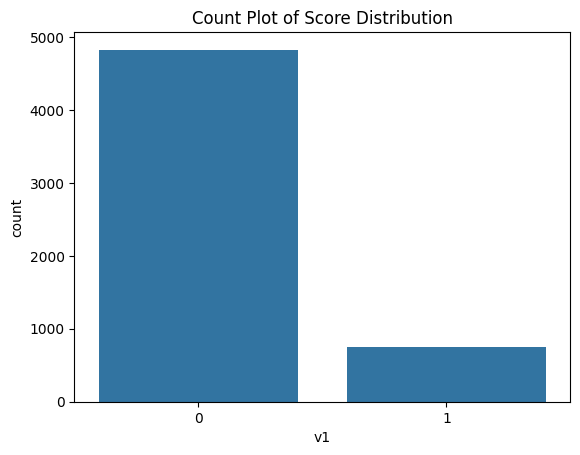

In [9]:
sns.countplot(x="v1", data=df)
plt.title("Count Plot of Score Distribution")
plt.xlabel("v1")
plt.ylabel("count")
plt.show()


In [10]:
from sklearn.utils import resample

df_majority = df[df['v1']==0]
df_minority = df[df['v1']==1]
print(df_majority.shape, df_minority.shape)


(4825, 2) (747, 2)


In [11]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,   
                                 n_samples=len(df_minority),    
                                 random_state=42)
df_resampled = pd.concat([df_majority_downsampled, df_minority])
df_resampled.reset_index(inplace = True)
df_resampled.drop('index', inplace=True,axis = 1)
df_resampled.head()

,v1,v2
0,0,"I am late,so call you tomorrow morning.take ca..."
1,0,U r too much close to my heart. If u go away i...
2,0,Wait &lt;#&gt; min..
3,0,Can you call me plz. Your number shows out of ...
4,0,MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOU...


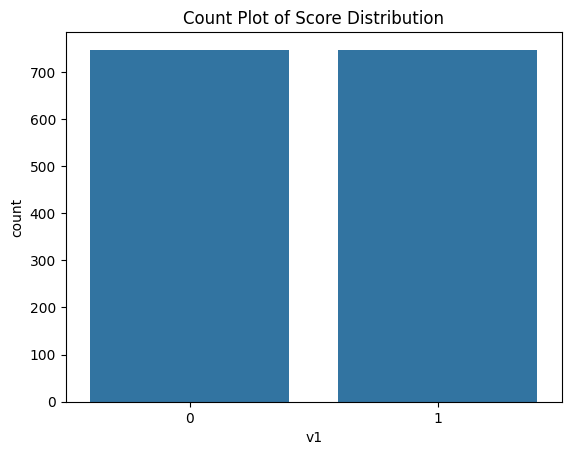

In [12]:
sns.countplot(x="v1", data=df_resampled)
plt.title("Count Plot of Score Distribution")
plt.xlabel("v1")
plt.ylabel("count")
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df_resampled, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

In [14]:
from nltk.corpus import stopwords
from string import punctuation
import nltk
import re
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [15]:
def add_meta_features(df, text_col):
    """
    Extracts an expanded set of numerical meta-features from raw text.
    """
    df_meta = df.copy()
    
    # --- Original Features ---
    df_meta['msg_length'] = df_meta[text_col].apply(lambda x: len(str(x)))
    
    df_meta['digit_density'] = df_meta[text_col].apply(
        lambda x: sum(c.isdigit() for c in str(x)) / max(len(str(x)), 1)
    )
    
    df_meta['uppercase_ratio'] = df_meta[text_col].apply(
        lambda x: sum(c.isupper() for c in str(x)) / max(len(str(x)), 1)
    )
    
    # --- NEW Advanced Features ---
    
    # 4. Has URL/Link (1 if true, 0 if false)
    df_meta['has_url'] = df_meta[text_col].apply(
        lambda x: 1 if re.search(r'http|www\.|(?:\.com|\.co|\.net)', str(x).lower()) else 0
    )
    
    # 5. Currency Symbol Count
    df_meta['currency_count'] = df_meta[text_col].apply(
        lambda x: len(re.findall(r'[\$£€₹]', str(x)))
    )
    
    # 6. Aggressive Punctuation Density (! and *)
    df_meta['aggro_punct_density'] = df_meta[text_col].apply(
        lambda x: len(re.findall(r'[!\*]', str(x))) / max(len(str(x)), 1)
    )
    
    # 7. Average Word Length
    def avg_word_length(text):
        words = str(text).split()
        if not words: return 0
        return sum(len(word) for word in words) / len(words)
        
    df_meta['avg_word_len'] = df_meta[text_col].apply(avg_word_length)
    
    return df_meta

In [16]:
def clean_text_pipeline(text):
    """
    Cleans a single text string: lowercases, removes special chars, 
    removes stopwords, and lemmatizes.
    """
    # 1. Convert to lowercase
    text = str(text).lower()
    
    # 2. Remove special characters (keep only alphanumeric and whitespace)
    text = re.sub(r'[^a-z0-9\s!$£*]', '', text)
    
    # 3 & 4. Tokenize (split), remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Rejoin the words back into a single string
    return ' '.join(cleaned_words)

def clean_dataset(df, text_column):
    """
    Takes a dataframe and the name of the text column, applies the cleaning 
    pipeline, and returns a new dataframe to prevent SettingWithCopy warnings.
    """
    # Create a copy so we don't accidentally modify the original data in-place
    df_clean = df.copy()
    df_clean[text_column] = df_clean[text_column].apply(clean_text_pipeline)
    return df_clean

text_col = 'v2' 


train_data_meta = add_meta_features(train_data, text_col)
val_data_meta = add_meta_features(val_data, text_col)
test_data_meta = add_meta_features(test_data, 'v2')

train_data_meta ['v2'] = train_data_meta[text_col].apply(clean_text_pipeline)
val_data_meta ['v2'] = val_data_meta[text_col].apply(clean_text_pipeline)
test_data_meta ['v2'] = test_data_meta[text_col].apply(clean_text_pipeline)

In [17]:
train_data_meta

,v1,v2,msg_length,digit_density,uppercase_ratio,has_url,currency_count,aggro_punct_density,avg_word_len
1143,1,pdatenow double min 1000 txts orange tariff la...,163,0.104294,0.116564,0,0,0.012270,5.833333
1155,1,hot live fantasy call 08707509020 20p per min ...,122,0.188525,0.237705,0,0,0.000000,4.125000
179,0,going thru different feelingwavering decision ...,142,0.000000,0.007042,0,0,0.000000,5.500000
134,0,thanks love torch bold,42,0.000000,0.047619,0,0,0.000000,3.777778
209,0,lay man! let know missed thought great day sen...,155,0.000000,0.070968,0,0,0.006452,3.875000
...,...,...,...,...,...,...,...,...,...
1380,1,win winner! mr foley ipod! exciting prize soon...,132,0.037879,0.068182,1,0,0.015152,4.320000
1180,1,thanks ringtone order reference number x29 mob...,157,0.101911,0.025478,0,0,0.000000,5.583333
508,0,india win level series mean record,51,0.000000,0.019608,0,0,0.000000,4.200000
1062,1,88066 88066 lost 3pound help,33,0.333333,0.515152,0,0,0.000000,4.666667


In [18]:
val_data_meta.head()

,v1,v2,msg_length,digit_density,uppercase_ratio,has_url,currency_count,aggro_punct_density,avg_word_len
164,0,ok thats great thanx lot,28,0.000000,0.035714,0,0,0.0,3.833333
1026,1,free tone hope enjoyed new content text stop 6...,129,0.155039,0.023256,1,0,0.0,6.222222
1086,1,guess ithis first time created web page wwwasj...,152,0.013158,0.131579,1,0,0.0,4.100000
815,1,want 2 get laid tonight want real dogging loca...,159,0.081761,0.088050,0,0,0.0,4.925926
1111,1,tried contact response offer new nokia fone ca...,130,0.084615,0.000000,0,0,0.0,4.240000


In [19]:
test_data_meta.head()

,v1,v2,msg_length,digit_density,uppercase_ratio,has_url,currency_count,aggro_punct_density,avg_word_len
949,1,urgent important information o2 user today luc...,163,0.012270,0.785276,1,0,0.006135,5.307692
900,1,panasonic bluetoothhdset free nokia free motor...,150,0.086667,0.166667,0,0,0.000000,5.863636
1339,1,want new video handset 750 time network min un...,135,0.103704,0.155556,0,0,0.000000,4.440000
983,1,hi ur lookin 4 saucy daytime fun wiv busty mar...,160,0.118750,0.137500,0,1,0.000000,5.440000
958,1,09066362231 urgent! mobile 07xxxxxxxxx £2000 b...,153,0.228758,0.098039,0,1,0.026144,5.160000


In [20]:
positive = train_data_meta[train_data_meta['v1'] == 1]
positive_list = positive['v2'].tolist()

negative = train_data_meta[train_data_meta['v1'] == 0]
negative_list = negative['v2'].tolist()

positive_all = " ".join(positive['v2'])
negative_all = " ".join(negative['v2'])

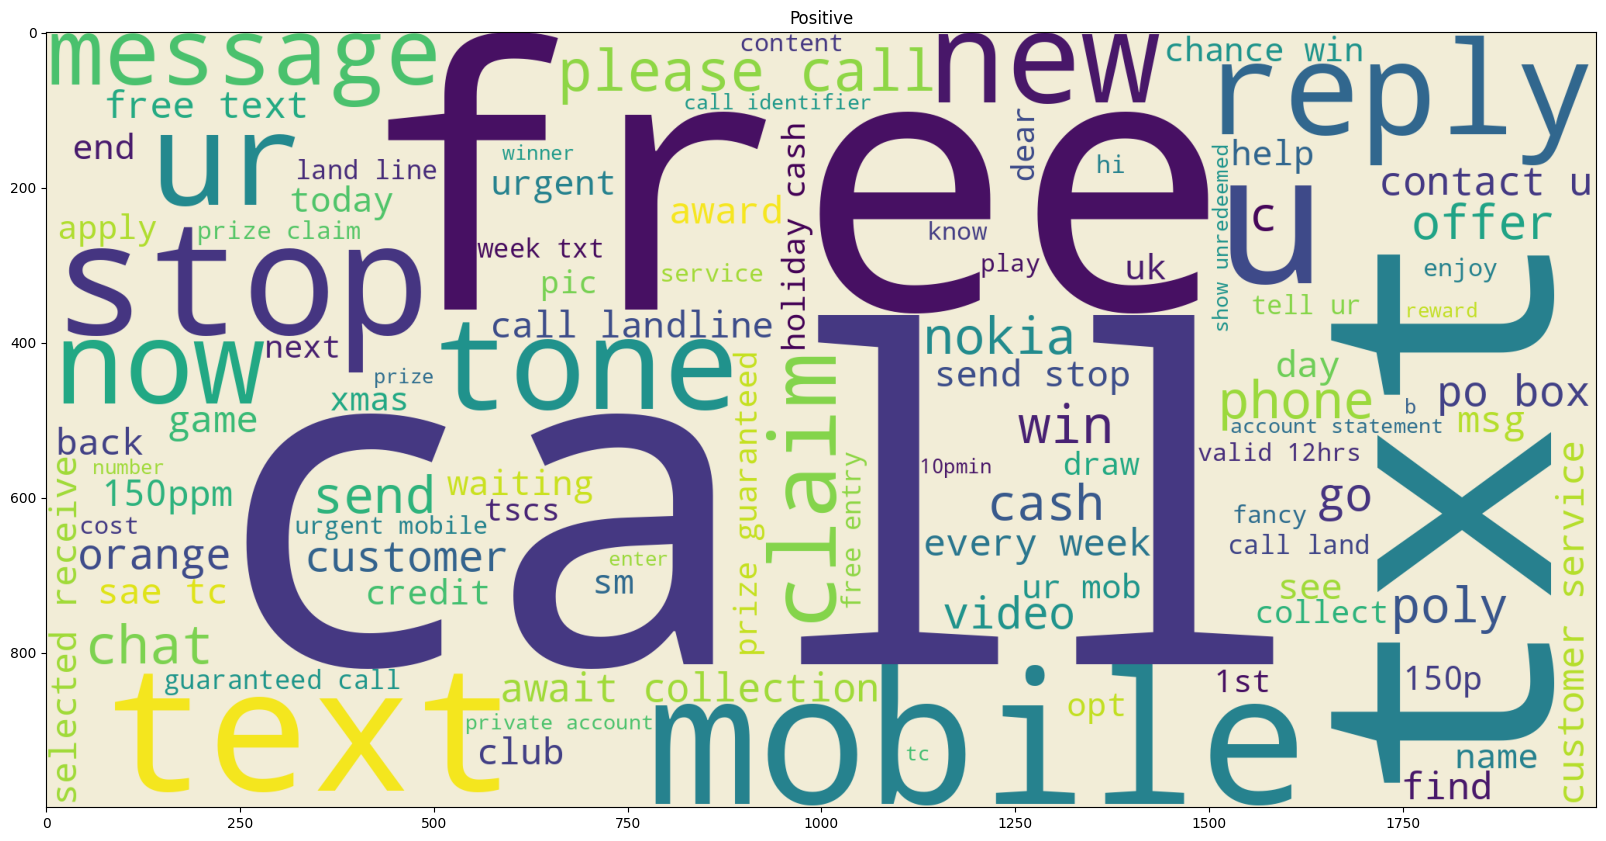

In [21]:
from wordcloud import WordCloud
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(positive_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("Positive")
plt.show()


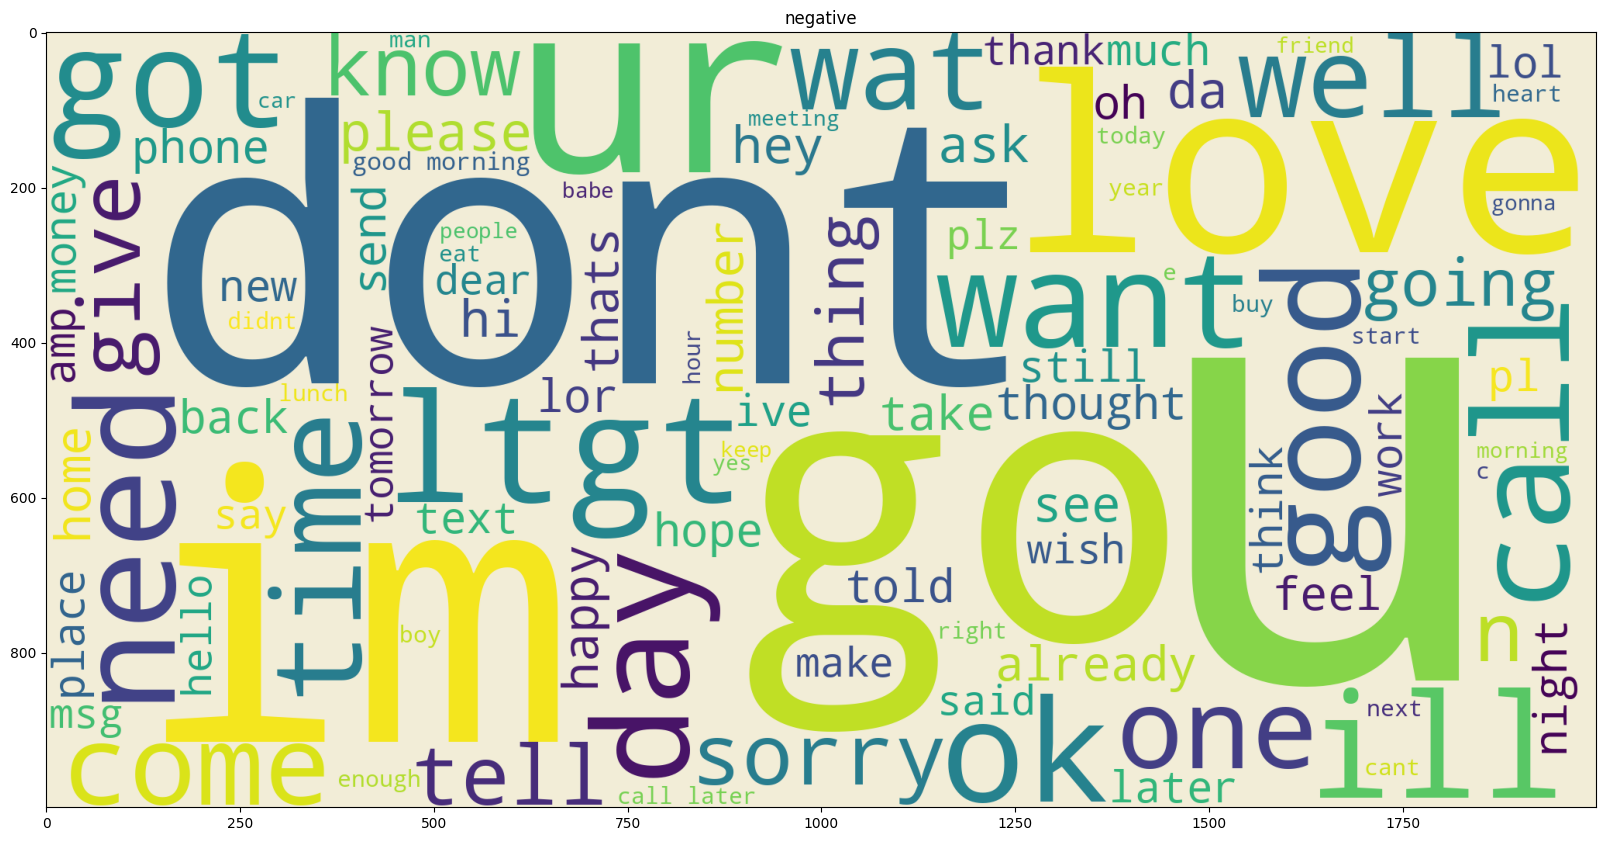

In [22]:
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(negative_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("negative")
plt.show()


In [23]:
y_train = train_data_meta['v1']
y_val = val_data_meta['v1']
y_test = test_data_meta['v1']

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Define the Preprocessor
# This tells scikit-learn which transformers to apply to which columns
preprocessor = ColumnTransformer(
    transformers=[
        # Apply TF-IDF (with bigrams) to the 'clean_message' column
        ('text', TfidfVectorizer(ngram_range=(1, 2)), 'v2'),
        
        # Apply StandardScaler to our engineered numerical columns
        ('num', StandardScaler(), [    'msg_length', 'digit_density', 'uppercase_ratio', 
    'has_url', 'currency_count', 'aggro_punct_density', 'avg_word_len'
])
    ]
)

# 2. Build the Final Pipeline
# Glue the preprocessor and the SVM model together
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(C=1.0, random_state=42, dual=False)) 
    # Note: dual=False is preferred when n_samples > n_features, but it works well generally
])

# 3. Train the Model
# We pass the entire dataframe; the ColumnTransformer handles splitting it up internally!
full_pipeline.fit(train_data_meta, y_train)

# 4. Predict and Evaluate on Validation Set
y_val_pred_meta = full_pipeline.predict(val_data_meta)

print("--- Meta-Feature + SVM Performance (Validation Set) ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_meta):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_meta))

--- Meta-Feature + SVM Performance (Validation Set) ---
Accuracy: 0.9707

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       120
           1       0.98      0.96      0.97       119

    accuracy                           0.97       239
   macro avg       0.97      0.97      0.97       239
weighted avg       0.97      0.97      0.97       239



In [25]:
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Define the XGBoost Classifier
# We set max_depth slightly lower to prevent overfitting on the sparse text data
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    tree_method='hist',
    device='cuda', # Offloads compute to the GPU (change to 'cpu' if CUDA isn't configured)
    random_state=42
)

# 2. Build the Preprocessor
# TF-IDF for text, and 'passthrough' leaves the numerical columns exactly as they are
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1, 2)), 'v2'),
        ('num', 'passthrough', [    'msg_length', 'digit_density', 'uppercase_ratio', 
    'has_url', 'currency_count', 'aggro_punct_density', 'avg_word_len'
])
    ]
)

# 3. Assemble and Train the Pipeline
xgb_combined_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', xgb_classifier)
])

print("Training Combined XGBoost Model...")
xgb_combined_pipeline.fit(train_data_meta, y_train)

# 4. Predict and Evaluate
y_val_pred_xgb_comb = xgb_combined_pipeline.predict(val_data_meta)

print("\n--- XGBoost (Text + Metadata) Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_xgb_comb):.4f}\n")
print(classification_report(y_val, y_val_pred_xgb_comb))

Training Combined XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:57:19] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:57:19] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost (Text + Metadata) Performance ---
Accuracy: 0.9540

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       120
           1       0.97      0.94      0.95       119

    accuracy                           0.95       239
   macro avg       0.95      0.95      0.95       239
weighted avg       0.95      0.95      0.95       239



# Just Metadata

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Isolate the numerical columns
features = [
    'msg_length', 'digit_density', 'uppercase_ratio', 
    'has_url', 'currency_count', 'aggro_punct_density', 'avg_word_len'
]

X_train_meta = train_data_meta[features]
X_val_meta = val_data_meta[features]

# 2. Build a streamlined pipeline
# We just need the scaler and the classifier now
meta_only_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(C=1.0, random_state=42, dual=False))
])

# 3. Train the model on JUST the metadata
meta_only_pipeline.fit(X_train_meta, y_train)

# 4. Predict and Evaluate on Validation Set
y_val_pred_meta_only = meta_only_pipeline.predict(X_val_meta)

# 5. Output the Results
print("--- Metadata ONLY Performance (Validation Set) ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_meta_only):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_meta_only))

--- Metadata ONLY Performance (Validation Set) ---
Accuracy: 0.9456

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       120
           1       0.98      0.91      0.94       119

    accuracy                           0.95       239
   macro avg       0.95      0.95      0.95       239
weighted avg       0.95      0.95      0.95       239



In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Build the Non-Linear SVM Pipeline
# We MUST scale the data. Distance metrics are the core of the RBF kernel.
rbf_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    
    # kernel='rbf' is the default, but we declare it explicitly here.
    # C controls the strictness of the margin, gamma controls the "bubble" size around data points.
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 2. Train the model on JUST the advanced metadata
print("Training Non-Linear (RBF) SVM on Metadata...")
rbf_svm_pipeline.fit(X_train_meta, y_train)

# 3. Predict and Evaluate
y_val_pred_rbf = rbf_svm_pipeline.predict(X_val_meta)

# 4. Output the Results
print("\n--- RBF Kernel SVM (Metadata ONLY) Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_rbf):.4f}\n")
print(classification_report(y_val, y_val_pred_rbf))

Training Non-Linear (RBF) SVM on Metadata...

--- RBF Kernel SVM (Metadata ONLY) Performance ---
Accuracy: 0.9582

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       120
           1       0.97      0.94      0.96       119

    accuracy                           0.96       239
   macro avg       0.96      0.96      0.96       239
weighted avg       0.96      0.96      0.96       239



In [28]:
# 1. Initialize a fresh model for the metadata
# We can allow deeper trees here since we only have 7 dense features
xgb_meta_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7, 
    tree_method='hist',
    device='cuda',
    random_state=42
)

# 2. Train directly on the advanced numerical features
print("Training Metadata-Only XGBoost Model...")
xgb_meta_model.fit(X_train_meta, y_train)

# 3. Predict and Evaluate
y_val_pred_xgb_meta = xgb_meta_model.predict(X_val_meta)

print("\n--- XGBoost (Metadata ONLY) Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_xgb_meta):.4f}\n")
print(classification_report(y_val, y_val_pred_xgb_meta))

Training Metadata-Only XGBoost Model...

--- XGBoost (Metadata ONLY) Performance ---
Accuracy: 0.9498

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       120
           1       0.96      0.94      0.95       119

    accuracy                           0.95       239
   macro avg       0.95      0.95      0.95       239
weighted avg       0.95      0.95      0.95       239



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:57:20] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:57:20] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
